In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("pre_final_database.csv")
df.shape

(5529, 37)

In [3]:
df.drop(columns=['live_interview_credit','pre_recorded_credit','ai_live_interview_credit','referral_credit'],inplace=True)
df.shape

(5529, 33)

In [4]:
binary_columns = ['jobma_catcher_type',
                  'is_premium',
                  'jobma_verified',
                  'interview_cost_type',
                  'ai_live_interview',
                  'confirmed',
                  'plan_type',
                  'is_unlimited',
                  'trial_account_type',
                  'billing_cycle_status'
                 ]

categorical_columns = ['subscription_status',
                       'jobma_catcher_title',
                       'jobma_catcher_otype',
                       'jobma_catcher_status',
                       'per_sub_user',
                       'company_size',
                       'number_of_logins',
                       'ai_interview_counts'
                      ]
                   
ordinal_columns = ['sub_user',
                   'days_since_creation',
                   'credit_amount',
                   'wallet_amount',
                   'subscription_amount',
                   'credit_given',
                   'currency_val',
                   'times_of_subscription',
                   'kits_count',
                   'position_created',
                   'number_of_invitations',
                   'pitchers_counts',
                   'def_interview_counts',
                   'interview_counts',
                   ]

In [5]:
used_columns = binary_columns + categorical_columns + ordinal_columns
X = df[used_columns].copy()
X.shape

(5529, 32)

In [6]:
# Clean binary values , # Remove negatives and  clamp to 0
def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0))
    
def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_ordinal(X):
    return X.clip(lower=0)

In [7]:
#pipeline 
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent'))
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('scaler', RobustScaler())
                                  ])

# Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', ordinal_pipeline, ordinal_columns)
                                              ])

pipeline = Pipeline([('preprocessing', preprocessor),
                     # ('scaling', MinMaxScaler()) #Problem shoul i use or not
                    ])

In [9]:
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_binary at 0x00000222A6DC0D30>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['jobma_catcher_type',
                                                   'is_premium',
                                                   'jobma_verified',
                                                   'interview_cost_type',
                                                   'ai_live_interview',
                                                   'confirmed', 'plan_type',
                                                   'is_unlim...
                                                                   FunctionTransformer(func=<function clean_ordinal at 0x00000222A6DC0F70>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['sub_user',
                                                   'days_since_creation',
                                                   'credit_amount',
                                                   'wallet_amount',
                                                   'subscription_amount',
                                                   'credit_given',
                                                   'currency_val',
                                                   'times_of_subscription',
                                                   'kits_count',
                                                   'position_created',
                                                   'number_of_invitations',
                                                   'pitchers_counts',
                                                   'def_interview_counts',
                                                   'interview_counts'])]))])

In [10]:
X_processed = pipeline.fit_transform(X)

In [12]:
X_processed.shape

(5529, 70)

DBSCAN found 147 clusters and 3064 noise points.
Silhouette Score (excluding noise): 0.791


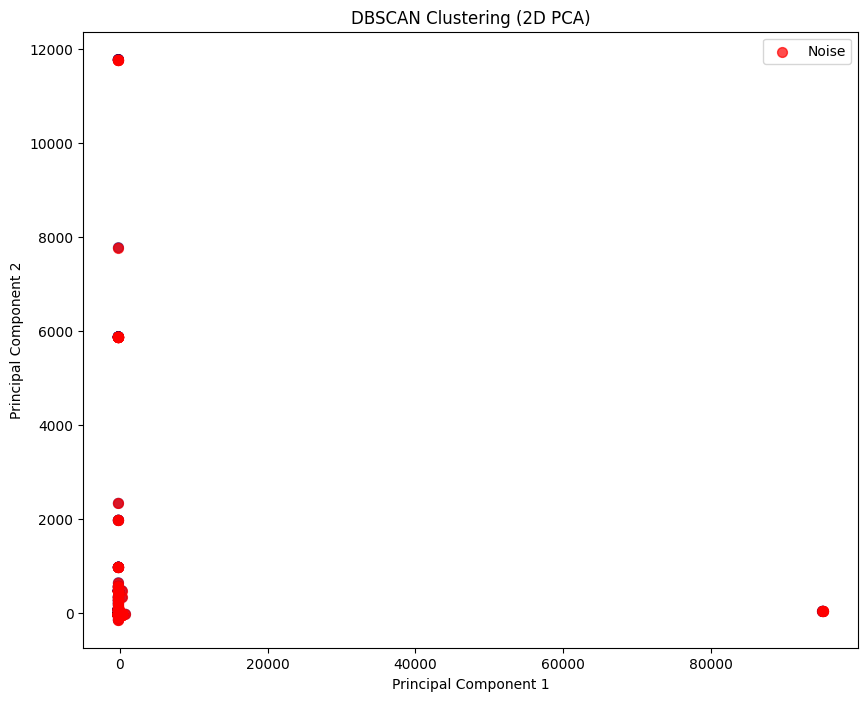

In [14]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_processed)

# Print the results
print(f"DBSCAN found {len(set(labels)) - (1 if -1 in labels else 0)} clusters and {list(labels).count(-1)} noise points.")

# Calculate silhouette score excluding noise
if len(set(labels)) > 1 and list(labels).count(-1) < len(labels):
    mask = labels != -1
    sil_score = silhouette_score(X_processed[mask], labels[mask])
    print(f"Silhouette Score (excluding noise): {sil_score:.3f}")
else:
    print("Silhouette Score is not applicable due to only one cluster or too many noise points.")

# Dimensionality reduction using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Create a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

# Highlight noise points (DBSCAN labels -1)
plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1], color='red', s=50, label='Noise', alpha=0.7)

# Add labels and title
plt.title("DBSCAN Clustering (2D PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()